In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = sns.load_dataset('titanic')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.describe(include=['object', 'category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage (%)', ascending=False)
missing_df

,Missing Count,Percentage (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


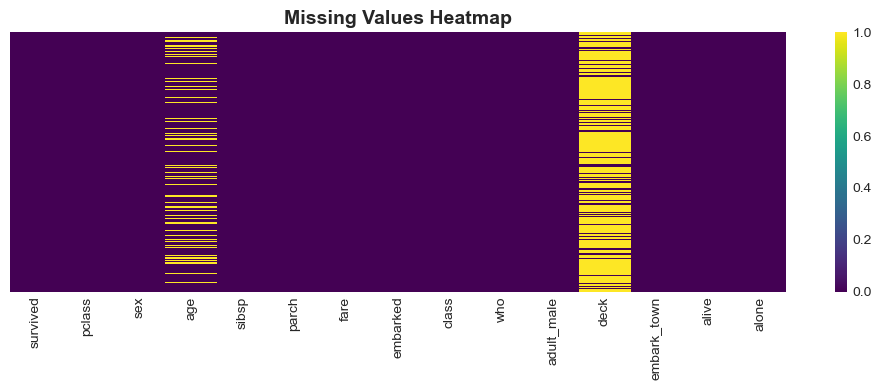

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
df_clean = df.copy()

df_clean['age'] = df_clean.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['deck'] = df_clean['deck'].cat.add_categories(['Unknown'])
df_clean['deck'] = df_clean['deck'].fillna('Unknown')

if 'alive' in df_clean.columns:
    df_clean = df_clean.drop('alive', axis=1)

print(df_clean.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alone          0
dtype: int64


In [8]:
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)
df_clean['age_group'] = pd.cut(df_clean['age'], 
                            bins=[0, 12, 18, 35, 60, 100],
                            labels=['Child', 'Teen', 'Young', 'Middle', 'Senior'])
df_clean['fare_per_person'] = df_clean['fare'] / df_clean['family_size']

print(f"New features created. Dataset shape: {df_clean.shape}")

New features created. Dataset shape: (891, 18)


In [9]:
survival_stats = {
    'Total Passengers': len(df_clean),
    'Survived': df_clean['survived'].sum(),
    'Overall Survival Rate': f"{df_clean['survived'].mean()*100:.2f}%",
    'Died': (df_clean['survived'] == 0).sum()
}
for key, value in survival_stats.items():
    print(f"{key}: {value}")

Total Passengers: 891
Survived: 342
Overall Survival Rate: 38.38%
Died: 549


In [10]:
survival_by_class = df_clean.groupby('pclass')['survived'].agg(['sum', 'count', 'mean'])
survival_by_class.columns = ['Survived', 'Total', 'Survival Rate']
survival_by_class['Survival Rate'] = (survival_by_class['Survival Rate'] * 100).round(2).astype(str) + '%'
survival_by_class

,Survived,Total,Survival Rate
pclass,,,
1,136,216,62.96%
2,87,184,47.28%
3,119,491,24.24%


In [11]:
survival_by_sex = df_clean.groupby('sex')['survived'].agg(['sum', 'count', 'mean'])
survival_by_sex.columns = ['Survived', 'Total', 'Survival Rate']
survival_by_sex['Survival Rate'] = (survival_by_sex['Survival Rate'] * 100).round(2).astype(str) + '%'
survival_by_sex

,Survived,Total,Survival Rate
sex,,,
female,233,314,74.2%
male,109,577,18.89%


In [12]:
age_stats = df_clean['age'].describe()
print("Age Distribution Statistics:")
print(age_stats)

Age Distribution Statistics:
count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: age, dtype: float64


In [13]:
fare_stats = df_clean['fare'].describe()
print("Fare Statistics:")
print(fare_stats)

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


In [14]:
numerical_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
correlation_matrix = df_clean[numerical_cols].corr()
print("Correlation Matrix:")
correlation_matrix.round(3)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000,-0.338,-0.060,-0.035,0.082,0.257,0.017
pclass,-0.338,1.000,-0.414,0.083,0.018,-0.549,0.066
age,-0.060,-0.414,1.000,-0.250,-0.176,0.123,-0.258
sibsp,-0.035,0.083,-0.250,1.000,0.415,0.160,0.891
parch,0.082,0.018,-0.176,0.415,1.000,0.216,0.783
fare,0.257,-0.549,0.123,0.160,0.216,1.000,0.217
family_size,0.017,0.066,-0.258,0.891,0.783,0.217,1.000


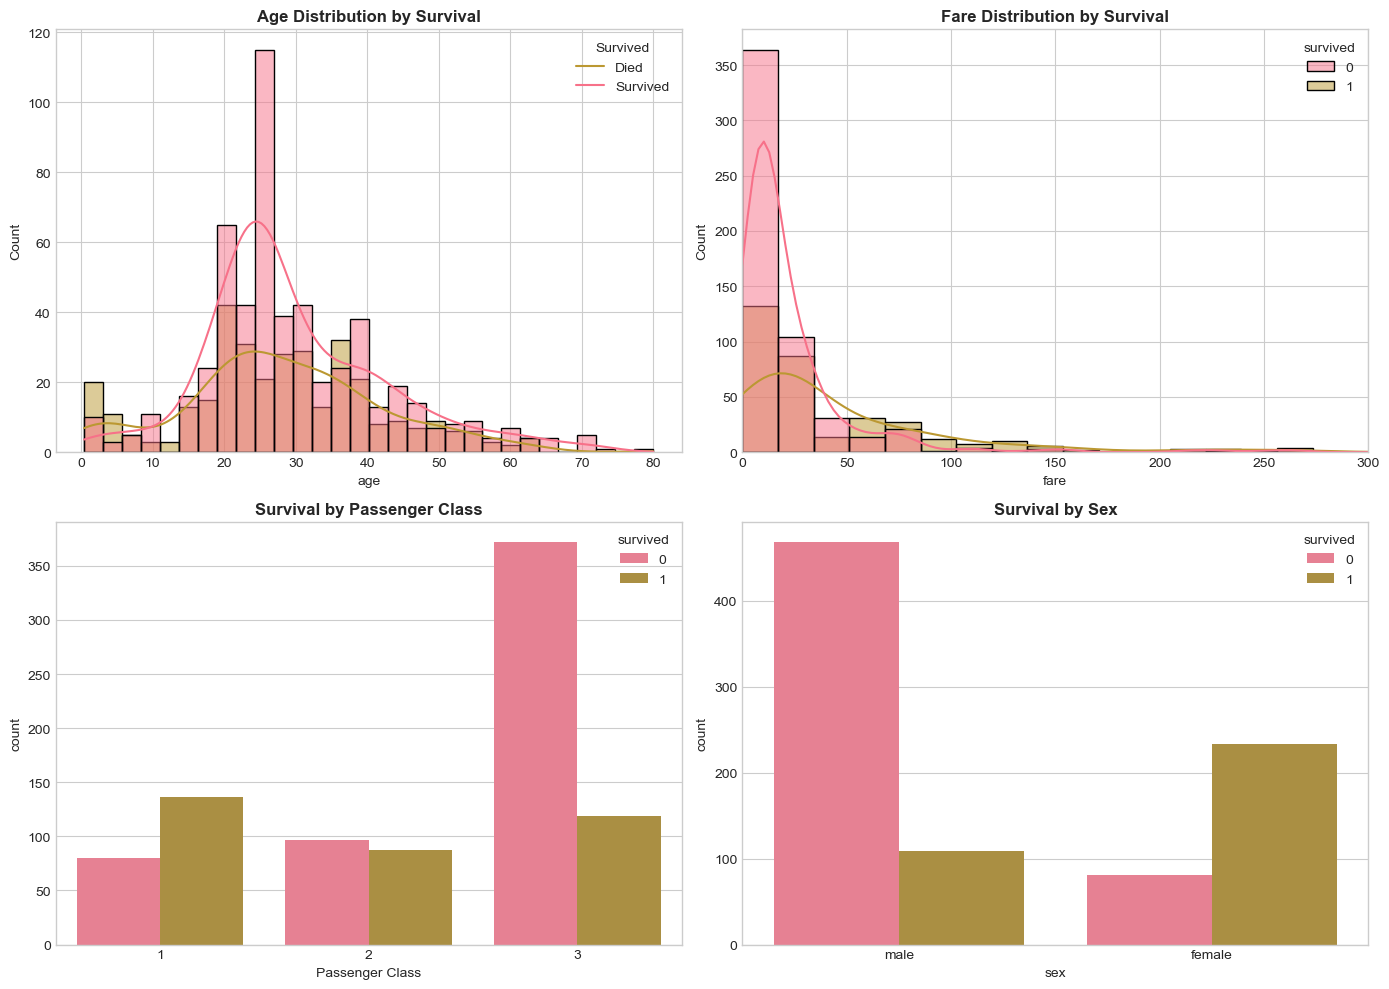

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df_clean, x='age', hue='survived', kde=True, ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[0, 0].legend(['Died', 'Survived'], title='Survived')

sns.histplot(data=df_clean, x='fare', hue='survived', kde=True, ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Fare Distribution by Survival', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(0, 300)

sns.countplot(data=df_clean, x='pclass', hue='survived', ax=axes[1, 0])
axes[1, 0].set_title('Survival by Passenger Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Passenger Class')

sns.countplot(data=df_clean, x='sex', hue='survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival by Sex', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

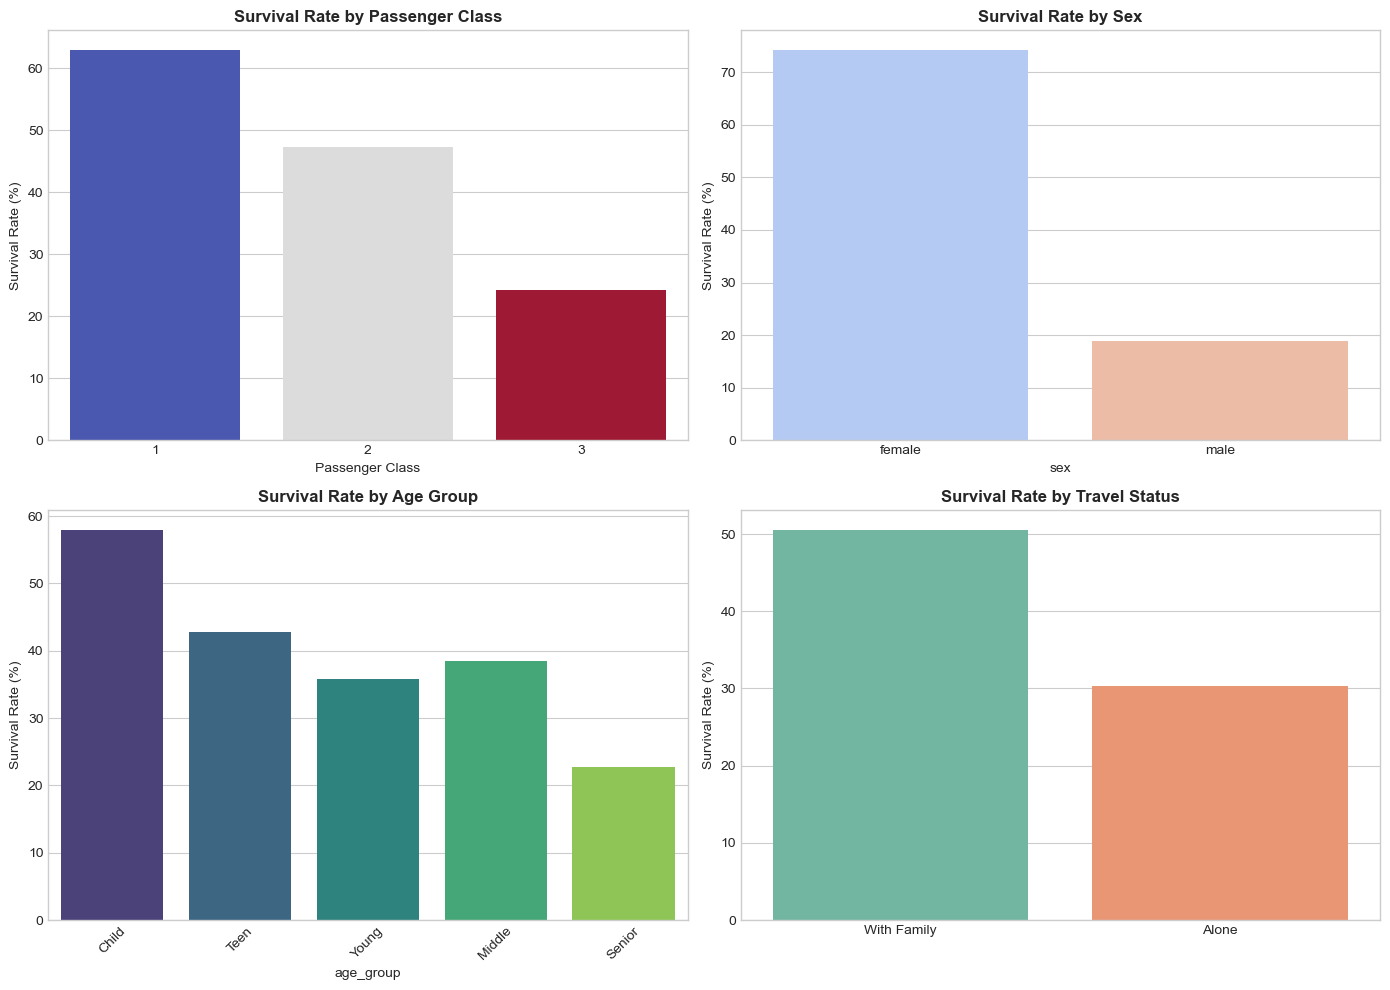

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by class
survival_rates = df_clean.groupby('pclass')['survived'].mean() * 100
sns.barplot(
    x=survival_rates.index,
    y=survival_rates.values,
    hue=survival_rates.index,
    ax=axes[0, 0],
    palette='coolwarm',
    legend=False
)
axes[0, 0].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate (%)')
axes[0, 0].set_xlabel('Passenger Class')

# Survival by sex
survival_by_sex = df_clean.groupby('sex')['survived'].mean() * 100
sns.barplot(
    x=survival_by_sex.index,
    y=survival_by_sex.values,
    hue=survival_by_sex.index,
    ax=axes[0, 1],
    palette='coolwarm',
    legend=False
)
axes[0, 1].set_title('Survival Rate by Sex', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate (%)')

# Survival by age group (fix pandas warning too)
age_survival = df_clean.groupby('age_group', observed=False)['survived'].mean() * 100
sns.barplot(
    x=age_survival.index,
    y=age_survival.values,
    hue=age_survival.index,
    ax=axes[1, 0],
    palette='viridis',
    legend=False
)
axes[1, 0].set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Survival Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Survival by family
family_survival = df_clean.groupby('is_alone')['survived'].mean() * 100
sns.barplot(
    x=['With Family', 'Alone'],
    y=family_survival.values,
    hue=['With Family', 'Alone'],
    ax=axes[1, 1],
    palette='Set2',
    legend=False
)
axes[1, 1].set_title('Survival Rate by Travel Status', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

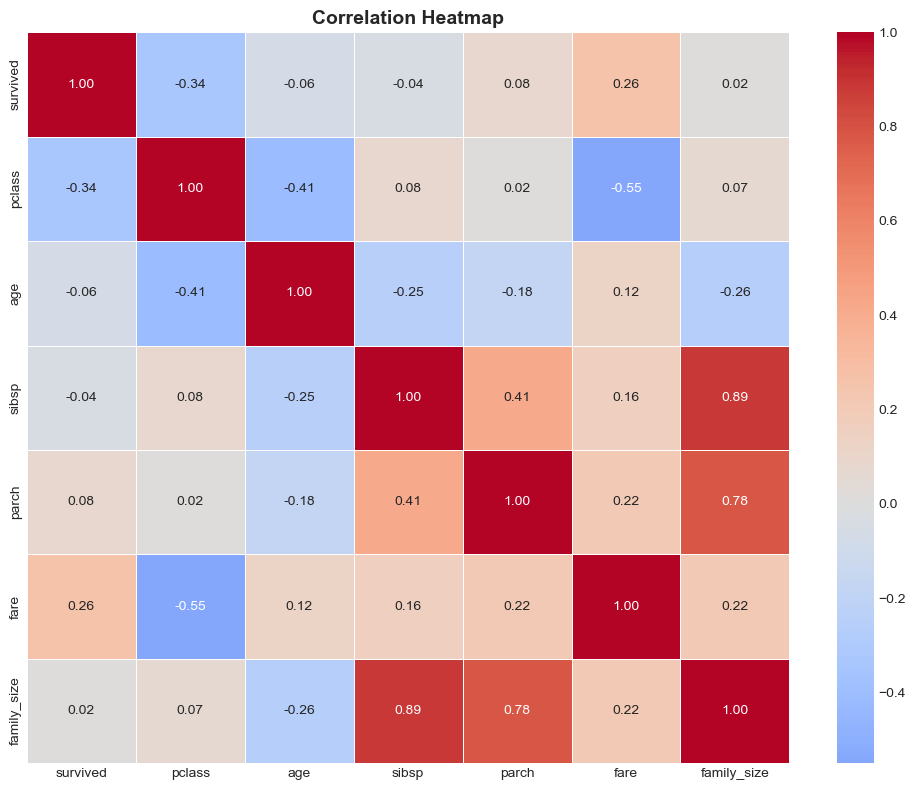

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

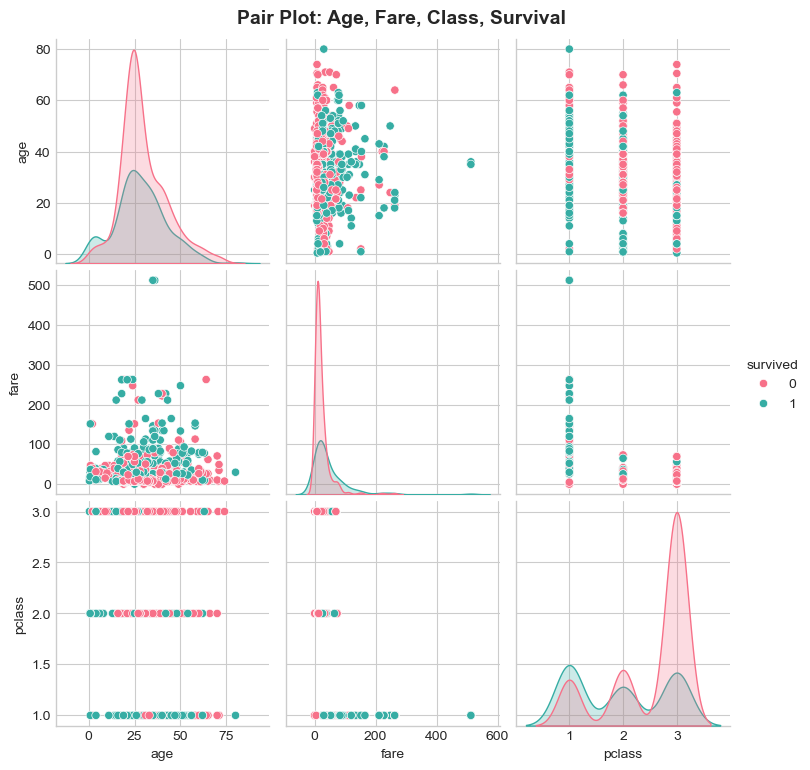

In [19]:
key_vars = ['age', 'fare', 'pclass', 'survived']
g = sns.pairplot(df_clean[key_vars], hue='survived', palette='husl', diag_kind='kde')
g.fig.suptitle('Pair Plot: Age, Fare, Class, Survival', y=1.02, fontsize=14, fontweight='bold')
plt.show()

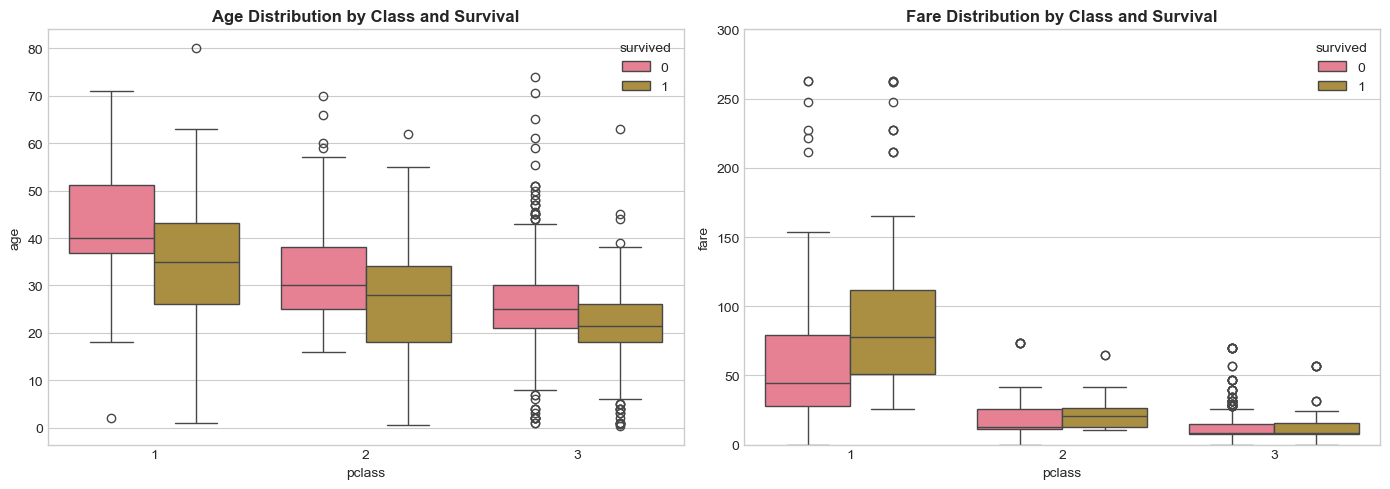

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='pclass', y='age', hue='survived', ax=axes[0])
axes[0].set_title('Age Distribution by Class and Survival', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='pclass', y='fare', hue='survived', ax=axes[1])
axes[1].set_title('Fare Distribution by Class and Survival', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

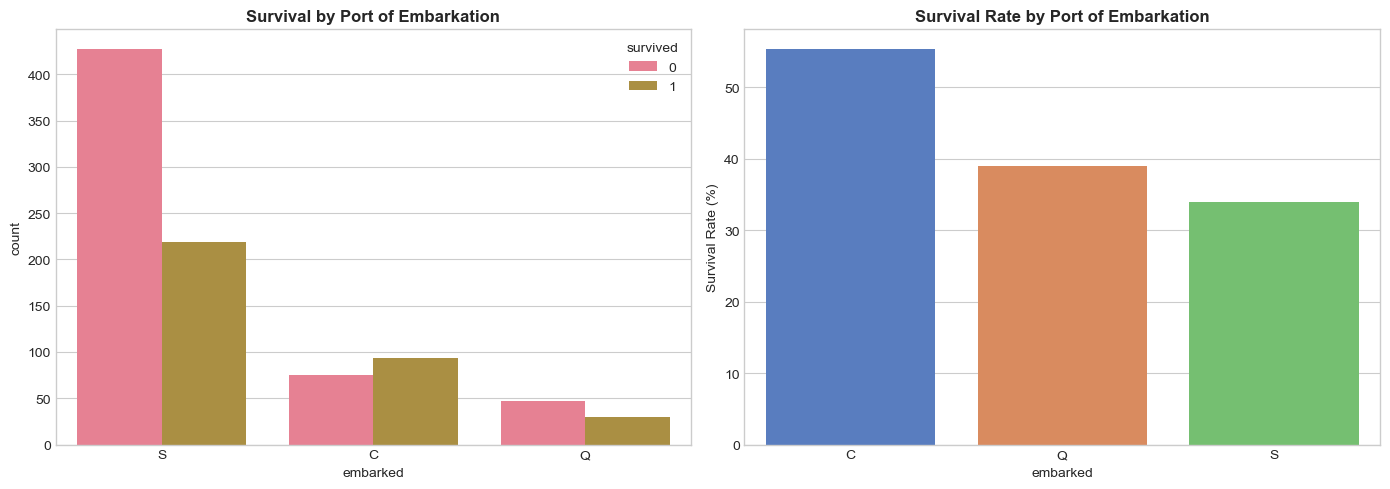

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='embarked', hue='survived', ax=axes[0])
axes[0].set_title('Survival by Port of Embarkation', fontsize=12, fontweight='bold')

embarked_survival = df_clean.groupby('embarked')['survived'].mean() * 100
sns.barplot(x=embarked_survival.index, y=embarked_survival.values,hue=embarked_survival.index, ax=axes[1], palette='muted')
axes[1].set_title('Survival Rate by Port of Embarkation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

In [25]:
print("KEY FINDINGS - TITANIC DISASTER ANALYSIS")

print(f"\n1. OVERALL SURVIVAL RATE: {df_clean['survived'].mean()*100:.1f}%")

print("\n2. SURVIVAL BY CLASS:")
for pclass in [1, 2, 3]:
    rate = df_clean[df_clean['pclass']==pclass]['survived'].mean()*100
    print(f"   - Class {pclass}: {rate:.1f}%")

print("\n3. SURVIVAL BY SEX:")
for sex in ['male', 'female']:
    rate = df_clean[df_clean['sex']==sex]['survived'].mean()*100
    print(f"   - {sex.capitalize()}: {rate:.1f}%")

print("\n4. DEMOGRAPHIC INSIGHTS:")
print(f"   - Average age: {df_clean['age'].mean():.1f} years")
print(f"   - Average fare: ${df_clean['fare'].mean():.2f}")
print(f"   - Percentage traveling alone: {df_clean['is_alone'].mean()*100:.1f}%")

print("\n5. STRONGEST CORRELATIONS WITH SURVIVAL:")
correlations = correlation_matrix['survived'].drop('survived').abs().sort_values(ascending=False)
for var, corr in correlations.items():
    print(f"   - {var}: {corr:.3f}")

KEY FINDINGS - TITANIC DISASTER ANALYSIS

1. OVERALL SURVIVAL RATE: 38.4%

2. SURVIVAL BY CLASS:
   - Class 1: 63.0%
   - Class 2: 47.3%
   - Class 3: 24.2%

3. SURVIVAL BY SEX:
   - Male: 18.9%
   - Female: 74.2%

4. DEMOGRAPHIC INSIGHTS:
   - Average age: 29.1 years
   - Average fare: $32.20
   - Percentage traveling alone: 60.3%

5. STRONGEST CORRELATIONS WITH SURVIVAL:
   - pclass: 0.338
   - fare: 0.257
   - parch: 0.082
   - age: 0.060
   - sibsp: 0.035
   - family_size: 0.017
